# Decision Tree and Random Forest Modeling
This notebook trains and compares Decision Tree and Random Forest models for roof suitability classification, including threshold tuning and export of prediction outputs.

In [25]:
# Import necessary libraries
import os
import numpy as np 
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv
import geopandas as gpd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


## Step 1: Load model dependencies
Import all required libraries for data preparation, model training, evaluation, and geospatial export.

## Step 2: Load input dataset
Use a project-relative path so the notebook works across different machines.

In [26]:
# Load model input data from project-relative paths
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_dir = project_root / "data"

candidate_files = [
    data_dir / "exports" / "preprocessing_step3" / "geospatial_join_complete_neukoelln.csv",
    data_dir / "exports" / "preprocessing_step3_geosp_join" / "geospatial_join_complete_neukoelln.csv",
    data_dir / "geospatial_join_complete_neukoelln.csv",
    data_dir / "geospatial_join_complete_neukoelln_dedup.csv",
]

# Dynamic fallback: search recursively for matching CSV names
for p in data_dir.rglob("*geospatial_join*neukoelln*.csv"):
    if p not in candidate_files:
        candidate_files.append(p)

data_file = next((p for p in candidate_files if p.exists()), None)

print("Using file:", data_file)
print("Exists:", data_file.exists() if data_file is not None else False)

if data_file is None or not data_file.exists():
    print("Checked paths:")
    for p in candidate_files:
        print(" -", p)
    raise FileNotFoundError("No input CSV found for model training.")

data = pd.read_csv(data_file)
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
data.head()

Using file: c:\Users\elbma\Nextcloud\1. Semester\AI in Human Water-Systems\berlin-green-roofs\data\exports\preprocessing_step3_geosp_join\geospatial_join_complete_neukoelln.csv
Exists: True
Shape: (53337, 18)
Columns: ['target_0_1', 'roof_area_', 'gruen20_m2', 'gruen20_p', 'gint20_m2', 'gex20_m2', 'bldg_index', 'bldg_ex_int', 'bldg_gebaeudefu', 'bldg_bauweise', 'bldg_ist_denkma', 'bldg_anzahl_unt', 'bldg_anzahl_obe', 'bldg_verschattu', 'bldg_verschat_1', 'bldg_verschat_2', 'bldg_suitable_a', 'bldg_suitabilit']


,target_0_1,roof_area_,gruen20_m2,gruen20_p,gint20_m2,gex20_m2,bldg_index,bldg_ex_int,bldg_gebaeudefu,bldg_bauweise,bldg_ist_denkma,bldg_anzahl_unt,bldg_anzahl_obe,bldg_verschattu,bldg_verschat_1,bldg_verschat_2,bldg_suitable_a,bldg_suitabilit
0,0,59.00,0.0,0.0,0.0,0.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,20.00,0.0,0.0,0.0,0.0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,108.00,0.0,0.0,0.0,0.0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,57.88,0.0,0.0,0.0,0.0,3,0,Wohnhaus,Freistehendes Einzelgebäude,False,0.0,1.0,0.95,0.05,0.0,57.88,100.0
4,0,11.00,0.0,0.0,0.0,0.0,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
# Select target column robustly
if "target_0_1" in data.columns:
    target_col = "target_0_1"
elif "ex_int" in data.columns:
    target_col = "ex_int"
else:
    raise KeyError("No target column found (expected 'target_0_1' or 'ex_int').")

# Exclude potential leakage and ID columns
leak_cols = [
    "importid", "index_righ", "gml_id_lef",
    "eex_int", "egruendach", "ext", "gex20_p",
    "bldg_index", "bldg_index_righ", "bldg_ex_int",
    "gint20_m2", "gex20_m2", "gruen20_m2", "gruen20_p",
    "bldg_solar_id"
]

y = data[target_col].copy()
X = data.drop(columns=[target_col] + leak_cols, errors="ignore").copy()

# Keep only numeric features and fill missing values
X = X.select_dtypes(include=["number"]).copy()
X = X.fillna(X.median(numeric_only=True))

# Convert target to integer labels
y = pd.to_numeric(y, errors="coerce")
valid_mask = y.notna()
X = X.loc[valid_mask].copy()
y = y.loc[valid_mask].astype(int)

# Ensure class labels are encoded as integers
if set(pd.Series(y).unique()) <= {0, 1}:
    le = LabelEncoder()
    le.fit([0, 1])
    y = le.transform(y)
else:
    le = LabelEncoder()
    y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Target:", target_col)
print("Classes:", list(le.classes_))
print("Class ratio:", pd.Series(y).value_counts(normalize=True))
print("Features:", X.shape[1])

Target: target_0_1
Classes: [np.int64(0), np.int64(1)]
Class ratio: 0    0.974183
1    0.025817
Name: proportion, dtype: float64
Features: 8


## Step 3: Prepare features and target
Clean the dataset, avoid leakage columns, encode the target, and create a stratified train/test split.

In [28]:
# Baseline model: majority-class predictor
majority = pd.Series(y_train).mode()[0]
baseline_pred = np.full(len(y_test), majority)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print("Baseline Balanced Accuracy:", balanced_accuracy_score(y_test, baseline_pred))
print("Baseline F1 macro:", f1_score(y_test, baseline_pred, average="macro"))

Baseline Accuracy: 0.9742219722534683
Baseline Balanced Accuracy: 0.5
Baseline F1 macro: 0.4934713451403067


## Step 4: Baseline comparison
Evaluate a majority-class baseline to benchmark model performance under class imbalance.

In [29]:
# Train Decision Tree classifier
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced",
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))
print("DT Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_dt))
print("DT F1 macro:", f1_score(y_test, y_pred_dt, average="macro"))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, zero_division=0))

DT Accuracy: 0.8237720284964379
DT Balanced Accuracy: 0.7236968938883689
DT F1 macro: 0.5274031093240132
[[8618 1775]
 [ 105  170]]
              precision    recall  f1-score   support

           0       0.99      0.83      0.90     10393
           1       0.09      0.62      0.15       275

    accuracy                           0.82     10668
   macro avg       0.54      0.72      0.53     10668
weighted avg       0.96      0.82      0.88     10668



## Step 5: Train Decision Tree
Train a class-balanced Decision Tree and evaluate standard classification metrics.

In [30]:
# Tune decision threshold for class 1 (Decision Tree)
# ===== THRESHOLD TUNING ON/OFF =====
# Set USE_THRESHOLD_TUNING = False to use default threshold 0.5
# Warning: This is suboptimal for imbalanced data and will miss many minority class samples!
USE_THRESHOLD_TUNING = True
# =================================

from sklearn.metrics import precision_recall_fscore_support

proba_dt = dt.predict_proba(X_test)[:, 1]

if USE_THRESHOLD_TUNING:
    thresholds = np.arange(0.05, 0.96, 0.05)
    rows = []

    for t in thresholds:
        y_pred_t = (proba_dt >= t).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(
            y_test, y_pred_t, average="binary", pos_label=1, zero_division=0
        )
        rows.append({"threshold": t, "precision_1": p, "recall_1": r, "f1_1": f1})

    res = pd.DataFrame(rows).sort_values("f1_1", ascending=False)
    print("Top 10 by class-1 F1 score:")
    print(res.head(10))

    best_t = float(res.iloc[0]["threshold"])
    print(f"\nBest threshold (class-1 F1): {best_t:.2f}")
else:
    best_t = 0.5
    print(f"Threshold tuning disabled. Using default threshold: {best_t}")

y_pred_best = (proba_dt >= best_t).astype(int)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, zero_division=0))

Top 10 by class-1 F1 score:
    threshold  precision_1  recall_1      f1_1
18       0.95     0.336842  0.232727  0.275269
16       0.85     0.173913  0.421818  0.246285
17       0.90     0.192478  0.316364  0.239340
15       0.80     0.141104  0.501818  0.220271
14       0.75     0.132964  0.523636  0.212077
13       0.70     0.115889  0.578182  0.193078
12       0.65     0.111720  0.592727  0.188005
11       0.60     0.109469  0.592727  0.184807
10       0.55     0.106935  0.600000  0.181518
9        0.50     0.087404  0.618182  0.153153

Best threshold (class-1 F1): 0.95

Confusion Matrix:
[[10267   126]
 [  211    64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     10393
           1       0.34      0.23      0.28       275

    accuracy                           0.97     10668
   macro avg       0.66      0.61      0.63     10668
weighted avg       0.96      0.97      0.97     10668



In [31]:
# Train Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))
print("RF F1 macro:", f1_score(y_test, y_pred_rf, average="macro"))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))

RF Accuracy: 0.9741282339707537
RF Balanced Accuracy: 0.5548241386247736
RF F1 macro: 0.5851439218499818
[[10361    32]
 [  244    31]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     10393
           1       0.49      0.11      0.18       275

    accuracy                           0.97     10668
   macro avg       0.73      0.55      0.59     10668
weighted avg       0.96      0.97      0.97     10668



## Step 6: Train and tune Random Forest
Train a Random Forest baseline and optimize its class-1 threshold for imbalanced performance.

In [32]:
# Tune decision threshold for class 1 (Random Forest)
# Note: Uses same USE_THRESHOLD_TUNING setting as Decision Tree
proba_rf = rf.predict_proba(X_test)[:, 1]

if USE_THRESHOLD_TUNING:
    thresholds = np.arange(0.05, 0.96, 0.05)
    rows_rf = []

    for t in thresholds:
        y_pred_t = (proba_rf >= t).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(
            y_test, y_pred_t, average="binary", pos_label=1, zero_division=0
        )
        rows_rf.append({"threshold": t, "precision_1": p, "recall_1": r, "f1_1": f1})

    res_rf = pd.DataFrame(rows_rf).sort_values("f1_1", ascending=False)
    print("Top 10 by class-1 F1 score (RF):")
    print(res_rf.head(10))

    best_t_rf = float(res_rf.iloc[0]["threshold"])
    print(f"\nBest RF threshold (class-1 F1): {best_t_rf:.2f}")
else:
    best_t_rf = 0.5
    print(f"Threshold tuning disabled. Using default threshold: {best_t_rf}")

y_pred_rf_best = (proba_rf >= best_t_rf).astype(int)
print("\nConfusion Matrix (RF, tuned threshold):")
print(confusion_matrix(y_test, y_pred_rf_best))
print("\nClassification Report (RF, tuned threshold):")
print(classification_report(y_test, y_pred_rf_best, zero_division=0))

Top 10 by class-1 F1 score (RF):
   threshold  precision_1  recall_1      f1_1
4       0.25     0.325472  0.250909  0.283368
3       0.20     0.270000  0.294545  0.281739
5       0.30     0.361446  0.218182  0.272109
1       0.10     0.168798  0.480000  0.249763
2       0.15     0.191617  0.349091  0.247423
6       0.35     0.393443  0.174545  0.241814
7       0.40     0.430000  0.156364  0.229333
0       0.05     0.128111  0.636364  0.213285
8       0.45     0.454545  0.127273  0.198864
9       0.50     0.484375  0.112727  0.182891

Best RF threshold (class-1 F1): 0.25

Confusion Matrix (RF, tuned threshold):
[[10250   143]
 [  206    69]]

Classification Report (RF, tuned threshold):
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     10393
           1       0.33      0.25      0.28       275

    accuracy                           0.97     10668
   macro avg       0.65      0.62      0.63     10668
weighted avg       0.96      0.97

In [33]:
# Generate suitability classes from Random Forest probabilities
proba_all = rf.predict_proba(X)[:, 1]

# Policy-based class shares for map readability in QGIS
high_share = 0.10      # top 10% => highly appropriate
medium_share = 0.25    # next 25% => medium appropriate

if high_share <= 0 or medium_share <= 0 or (high_share + medium_share) >= 1:
    raise ValueError("Invalid class share setup. Require: high_share > 0, medium_share > 0, high+medium < 1.")

# Keep raw probability for transparent QA in QGIS
data["suitability_score"] = proba_all.round(6)

# Robust class assignment via rank percentiles (stable even when many probabilities are exactly 0.0)
rank_pct = pd.Series(proba_all).rank(method="first", pct=True).to_numpy()
medium_cut = 1 - (high_share + medium_share)
high_cut = 1 - high_share

data["suitability_012"] = np.select(
    [
        rank_pct < medium_cut,
        (rank_pct >= medium_cut) & (rank_pct < high_cut),
        rank_pct >= high_cut,
    ],
    [0, 1, 2],
)

data["suitability_label"] = data["suitability_012"].map({
    0: "not appropriate",
    1: "medium appropriate",
    2: "highly appropriate",
})

# Optional binary recommendation using tuned RF threshold from test split
if "best_t_rf" in globals():
    data["suitable_binary_rf"] = (proba_all >= best_t_rf).astype(int)
else:
    data["suitable_binary_rf"] = (proba_all >= 0.5).astype(int)

print(f"Rank cutoffs (RF): medium_cut={medium_cut:.2f}, high_cut={high_cut:.2f}")
print("Suitability class counts:")
print(data["suitability_012"].value_counts().sort_index())
print("\nProbability summary:")
print(pd.Series(proba_all).describe())
print("\nPreview:")
print(data[["suitability_score", "suitability_012", "suitability_label", "suitable_binary_rf"]].head())

# Export 1: CSV
solution_dir = data_dir / "exports" / "solution"
solution_dir.mkdir(parents=True, exist_ok=True)

csv_out = solution_dir / "roof_suitability_predictions.csv"
data.to_csv(csv_out, index=False, encoding="utf-8")
print("Saved CSV:", csv_out)

# Export 2: GeoPackage (preferred for QGIS) and Shapefile fallback
geo_candidates = [
    data_dir / "exports" / "preprocessing_step3_geosp_join" / "geospatial_join_complete_neukoelln.gpkg",
    data_dir / "exports" / "preprocessing_step3_geosp_join" / "geospatial_join_complete_neukoelln.shp",
]
geo_file = next((p for p in geo_candidates if p.exists()), None)

if geo_file is None:
    raise FileNotFoundError(
        f"No geospatial file found for export. Checked: {[str(p) for p in geo_candidates]}"
    )

geo = gpd.read_file(geo_file)

if len(geo) != len(data):
    raise ValueError(
        f"Row count mismatch for safe merge (geo={len(geo)}, data={len(data)})."
    )

geo = geo.reset_index(drop=True)
pred = data[["suitability_score", "suitability_012", "suitability_label", "suitable_binary_rf"]].reset_index(drop=True)

geo["suit_scr"] = pred["suitability_score"]
geo["suit_012"] = pred["suitability_012"]
geo["suit_lbl"] = pred["suitability_label"]
geo["suit_bin"] = pred["suitable_binary_rf"]

gpkg_out = solution_dir / "roof_suitability_predictions.gpkg"
geo.to_file(gpkg_out, driver="GPKG")
print("Saved GPKG:", gpkg_out)

shp_out = solution_dir / "roof_suitability_predictions.shp"
geo.to_file(shp_out, driver="ESRI Shapefile", encoding="utf-8")
print("Saved SHP:", shp_out)

Rank cutoffs (RF): medium_cut=0.65, high_cut=0.90
Suitability class counts:
suitability_012
0    34669
1    13334
2     5334
Name: count, dtype: int64

Probability summary:
count    53337.000000
mean         0.025489
std          0.106198
min          0.000000
25%          0.000000
50%          0.000000
75%          0.005000
max          1.000000
dtype: float64

Preview:
   suitability_score  suitability_012   suitability_label  suitable_binary_rf
0             0.0000                0     not appropriate                   0
1             0.0000                0     not appropriate                   0
2             0.0000                0     not appropriate                   0
3             0.0025                1  medium appropriate                   0
4             0.0000                0     not appropriate                   0
Saved CSV: c:\Users\elbma\Nextcloud\1. Semester\AI in Human Water-Systems\berlin-green-roofs\data\exports\solution\roof_suitability_predictions.csv
Saved GPKG

C:\Users\elbma\AppData\Local\Temp\ipykernel_36828\487987198.py:88: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  geo.to_file(shp_out, driver="ESRI Shapefile", encoding="utf-8")
c:\Users\elbma\Nextcloud\1. Semester\AI in Human Water-Systems\berlin-green-roofs\.venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'bldg_ex_int' to 'bldg_ex_in'
  ogr_write(
c:\Users\elbma\Nextcloud\1. Semester\AI in Human Water-Systems\berlin-green-roofs\.venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'bldg_gebaeudefu' to 'bldg_gebae'
  ogr_write(
c:\Users\elbma\Nextcloud\1. Semester\AI in Human Water-Systems\berlin-green-roofs\.venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'bldg_bauweise' to 'bldg_bauwe'
  ogr_write(
c:\Users\elbma\Nextcloud\1. Semester\AI in Human Water-Systems\berlin-green-roofs\.venv\Lib\site-packages\p

Saved SHP: c:\Users\elbma\Nextcloud\1. Semester\AI in Human Water-Systems\berlin-green-roofs\data\exports\solution\roof_suitability_predictions.shp


## Step 7: Evaluation Dashboard
This section creates a compact evaluation summary table and diagnostic plots for baseline, Decision Tree, and Random Forest results.

Evaluation summary (sorted by balanced accuracy):
                model  accuracy  balanced_accuracy  f1_macro  precision_class1  recall_class1
        Decision Tree    0.8238             0.7237    0.5274            0.0874         0.6182
Random Forest (tuned)    0.9673             0.6186    0.6333            0.3255         0.2509
Decision Tree (tuned)    0.9684             0.6103    0.6296            0.3368         0.2327
        Random Forest    0.9741             0.5548    0.5851            0.4921         0.1127
             Baseline    0.9742             0.5000    0.4935            0.0000         0.0000

Saved summary table: c:\Users\elbma\Nextcloud\1. Semester\AI in Human Water-Systems\berlin-green-roofs\data\exports\solution\model_evaluation_summary.csv

Class distribution:
split  n_samples  class_1_share
train      42669         0.0258
 test      10668         0.0258


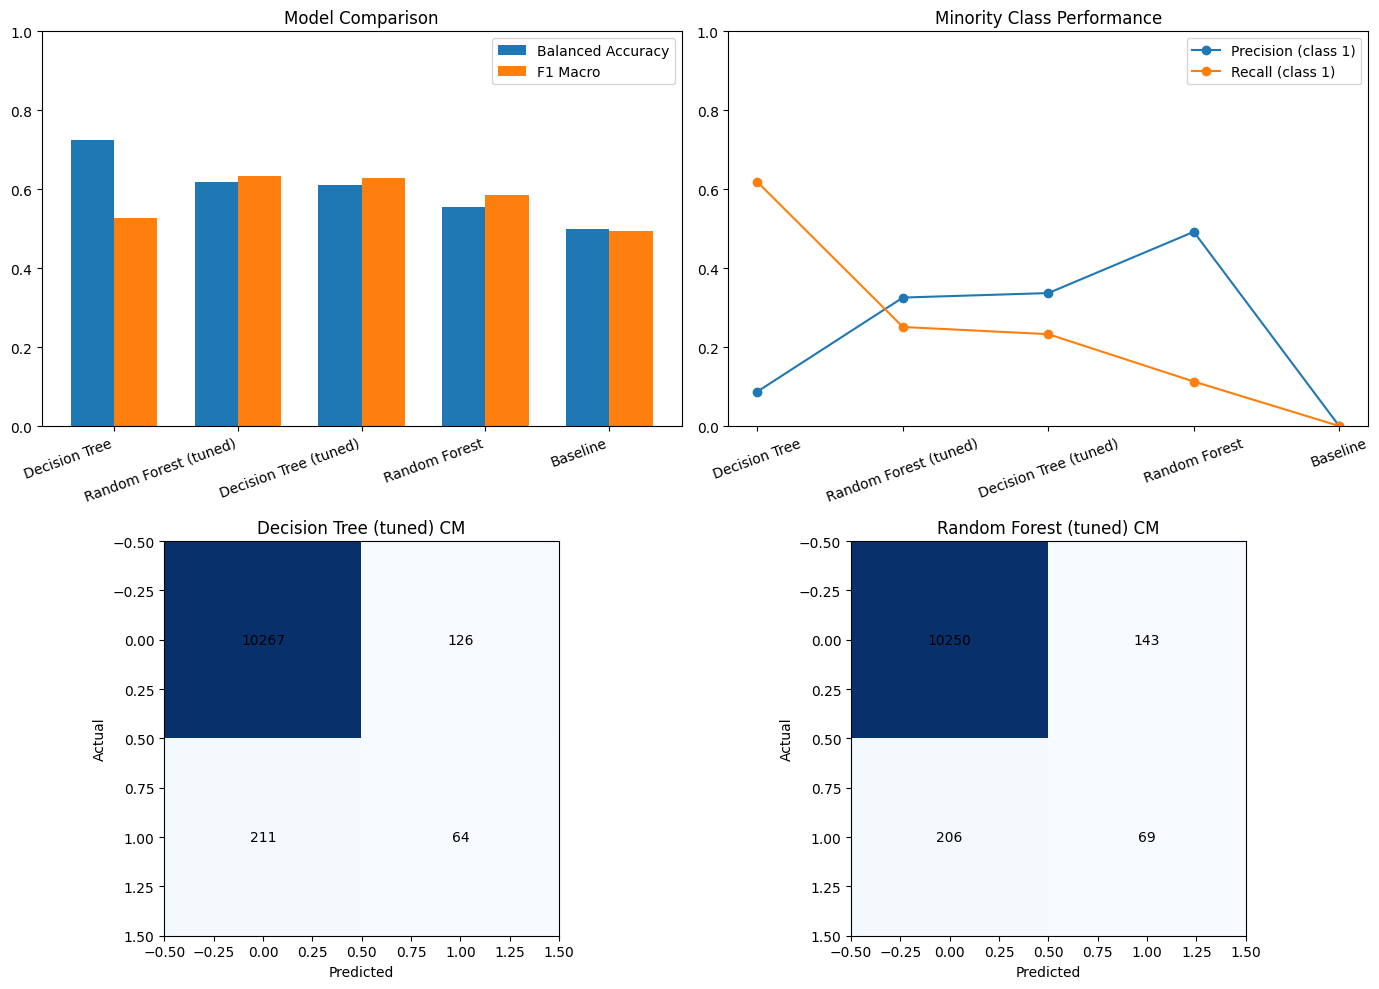

Saved dashboard plot: c:\Users\elbma\Nextcloud\1. Semester\AI in Human Water-Systems\berlin-green-roofs\data\exports\solution\model_evaluation_dashboard.png


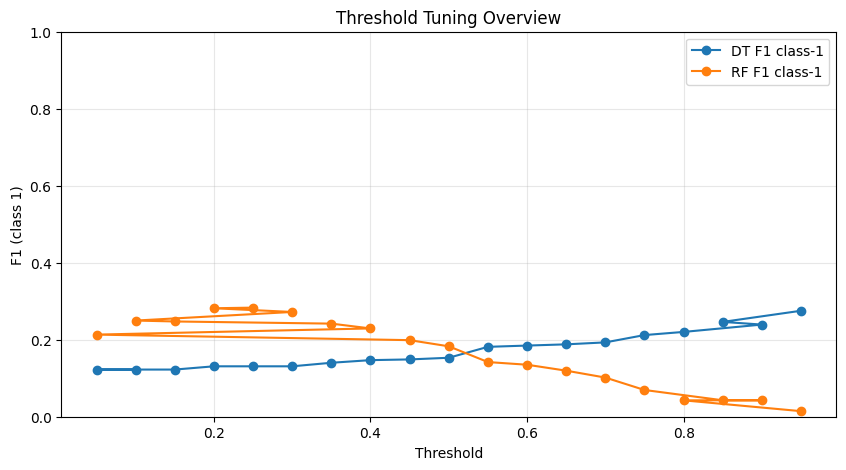

Saved threshold plot: c:\Users\elbma\Nextcloud\1. Semester\AI in Human Water-Systems\berlin-green-roofs\data\exports\solution\threshold_tuning_overview.png


In [34]:
# Build evaluation summary table and plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

# Collect available model predictions
model_preds = {
    "Baseline": baseline_pred if "baseline_pred" in globals() else None,
    "Decision Tree": y_pred_dt if "y_pred_dt" in globals() else None,
    "Decision Tree (tuned)": y_pred_best if "y_pred_best" in globals() else None,
    "Random Forest": y_pred_rf if "y_pred_rf" in globals() else None,
    "Random Forest (tuned)": y_pred_rf_best if "y_pred_rf_best" in globals() else None,
}

def eval_row(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_class1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_class1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

rows = []
for name, pred in model_preds.items():
    if pred is not None:
        rows.append(eval_row(name, y_test, pred))

eval_df = pd.DataFrame(rows)
if eval_df.empty:
    raise RuntimeError("No model predictions found. Run training cells first.")

eval_df = eval_df.sort_values("balanced_accuracy", ascending=False).reset_index(drop=True)
print("Evaluation summary (sorted by balanced accuracy):")
print(eval_df.round(4).to_string(index=False))

# Save summary table for reporting
solution_dir = data_dir / "exports" / "solution"
solution_dir.mkdir(parents=True, exist_ok=True)
summary_csv = solution_dir / "model_evaluation_summary.csv"
eval_df.to_csv(summary_csv, index=False)
print(f"\nSaved summary table: {summary_csv}")

# Class distribution table for interpretation
class_dist = pd.DataFrame({
    "split": ["train", "test"],
    "n_samples": [len(y_train), len(y_test)],
    "class_1_share": [float(np.mean(y_train == 1)), float(np.mean(y_test == 1))],
})
print("\nClass distribution:")
print(class_dist.round(4).to_string(index=False))

# Plot key model diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Balanced accuracy and macro F1 by model
plot_df = eval_df.copy()
x = np.arange(len(plot_df))
width = 0.35
axes[0, 0].bar(x - width / 2, plot_df["balanced_accuracy"], width, label="Balanced Accuracy")
axes[0, 0].bar(x + width / 2, plot_df["f1_macro"], width, label="F1 Macro")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(plot_df["model"], rotation=20, ha="right")
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Model Comparison")
axes[0, 0].legend()

# Plot 2: Precision/Recall for positive class
axes[0, 1].plot(plot_df["model"], plot_df["precision_class1"], marker="o", label="Precision (class 1)")
axes[0, 1].plot(plot_df["model"], plot_df["recall_class1"], marker="o", label="Recall (class 1)")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis="x", rotation=20)
axes[0, 1].set_title("Minority Class Performance")
axes[0, 1].legend()

# Helper for confusion matrix plotting
def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

# Plot 3: Confusion matrix (best DT available)
if "y_pred_best" in globals():
    plot_cm(axes[1, 0], y_test, y_pred_best, "Decision Tree (tuned) CM")
elif "y_pred_dt" in globals():
    plot_cm(axes[1, 0], y_test, y_pred_dt, "Decision Tree CM")
else:
    axes[1, 0].axis("off")

# Plot 4: Confusion matrix (best RF available)
if "y_pred_rf_best" in globals():
    plot_cm(axes[1, 1], y_test, y_pred_rf_best, "Random Forest (tuned) CM")
elif "y_pred_rf" in globals():
    plot_cm(axes[1, 1], y_test, y_pred_rf, "Random Forest CM")
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plot_png = solution_dir / "model_evaluation_dashboard.png"
plt.savefig(plot_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved dashboard plot: {plot_png}")

# Optional threshold plots if tuning tables are present
if "res" in globals() or "res_rf" in globals():
    plt.figure(figsize=(10, 5))
    if "res" in globals() and not res.empty:
        plt.plot(res["threshold"], res["f1_1"], marker="o", label="DT F1 class-1")
    if "res_rf" in globals() and not res_rf.empty:
        plt.plot(res_rf["threshold"], res_rf["f1_1"], marker="o", label="RF F1 class-1")
    plt.xlabel("Threshold")
    plt.ylabel("F1 (class 1)")
    plt.title("Threshold Tuning Overview")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    thr_png = solution_dir / "threshold_tuning_overview.png"
    plt.savefig(thr_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved threshold plot: {thr_png}")


FEATURE IMPORTANCE & BALANCING ANALYSIS

Top 10 Most Important Features (Random Forest):
        feature  importance
     roof_area_     0.29962
bldg_suitable_a     0.20477
bldg_suitabilit     0.11187
bldg_anzahl_obe     0.09961
bldg_verschattu     0.09743
bldg_verschat_1     0.09515
bldg_verschat_2     0.08932
bldg_anzahl_unt     0.00222


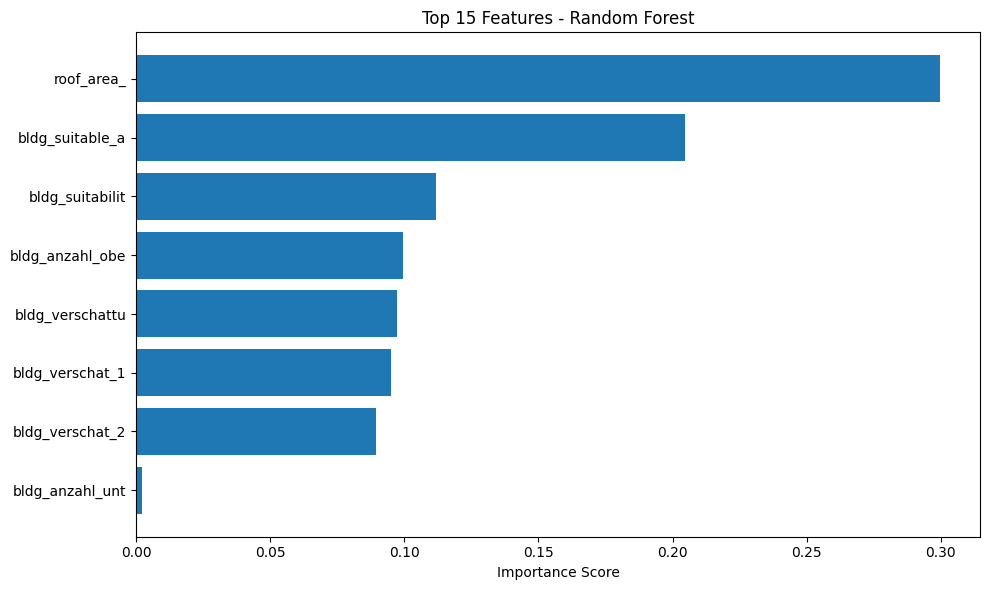


Saved feature importance plot: c:\Users\elbma\Nextcloud\1. Semester\AI in Human Water-Systems\berlin-green-roofs\data\exports\solution\feature_importance_top15.png

----------------------------------------------------------------------
CLASS BALANCE ANALYSIS
----------------------------------------------------------------------

Predicted Class Distribution & Recall:
                Model  Class_0_Predicted  Class_1_Predicted  Total  Class_1_%  Recall_Class_1
             Baseline              10668                  0  10668       0.00            0.00
        Decision Tree               8723               1945  10668      18.23            0.62
Decision Tree (tuned)              10478                190  10668       1.78            0.23
        Random Forest              10605                 63  10668       0.59            0.11
Random Forest (tuned)              10456                212  10668       1.99            0.25

✓ Actual test set: Class 0 = 10393, Class 1 = 275 (2.6%)


C:\Users\elbma\AppData\Local\Temp\ipykernel_36828\950737134.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(models_in_balance, rotation=20, ha="right")


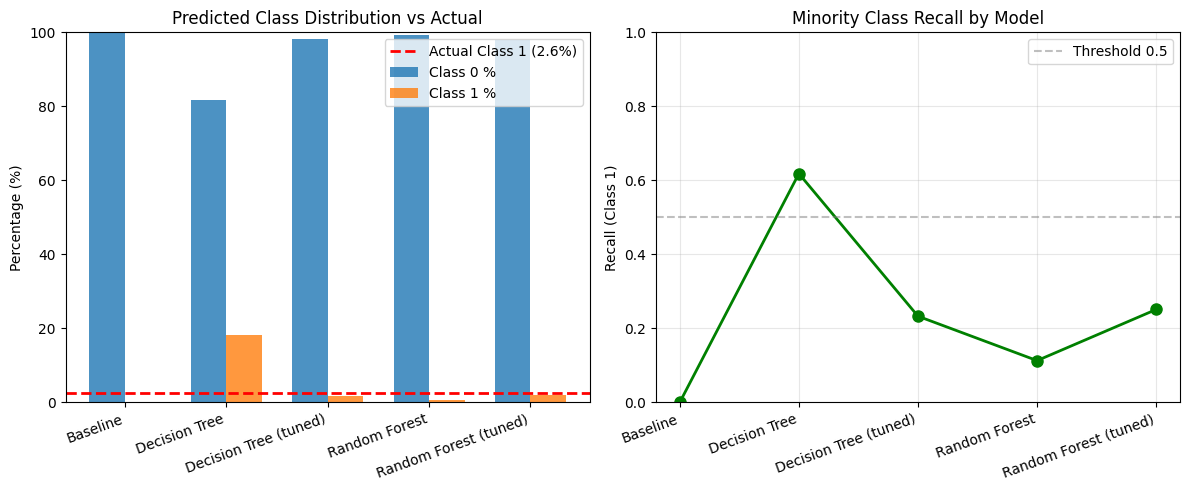


Saved balance analysis plot: c:\Users\elbma\Nextcloud\1. Semester\AI in Human Water-Systems\berlin-green-roofs\data\exports\solution\class_balance_analysis.png

✓ Feature importance & balancing analysis completed!


In [35]:

# === BONUS: Feature Importance & Balancing Analysis ===
# Show which features drive the predictions and how well models balance class detection

print("\n" + "="*70)
print("FEATURE IMPORTANCE & BALANCING ANALYSIS")
print("="*70)

# 1. Feature Importance from Random Forest (most robust)
if "rf" in globals():
    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": rf.feature_importances_,
    }).sort_values("importance", ascending=False)
    
    print("\nTop 10 Most Important Features (Random Forest):")
    print(feature_importance.head(10).round(5).to_string(index=False))
    
    # Plot top 15 features
    fig, ax = plt.subplots(figsize=(10, 6))
    top_n = min(15, len(feature_importance))
    top_features = feature_importance.head(top_n)
    ax.barh(range(top_n), top_features["importance"].values)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features["feature"].values)
    ax.set_xlabel("Importance Score")
    ax.set_title("Top 15 Features - Random Forest")
    ax.invert_yaxis()
    plt.tight_layout()
    
    solution_dir = data_dir / "exports" / "solution"
    solution_dir.mkdir(parents=True, exist_ok=True)
    feat_png = solution_dir / "feature_importance_top15.png"
    plt.savefig(feat_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved feature importance plot: {feat_png}")

# 2. Detailed Class Balance Analysis
print("\n" + "-"*70)
print("CLASS BALANCE ANALYSIS")
print("-"*70)

balance_analysis = []

for name, pred in model_preds.items():
    if pred is not None:
        class_0_count = (pred == 0).sum()
        class_1_count = (pred == 1).sum()
        total = len(pred)
        class_1_pct = (class_1_count / total) * 100
        
        balance_analysis.append({
            "Model": name,
            "Class_0_Predicted": class_0_count,
            "Class_1_Predicted": class_1_count,
            "Total": total,
            "Class_1_%": class_1_pct,
            "Recall_Class_1": recall_score(y_test, pred, pos_label=1, zero_division=0),
        })

balance_df = pd.DataFrame(balance_analysis)
print("\nPredicted Class Distribution & Recall:")
print(balance_df.round(2).to_string(index=False))

# Actual test set balance for reference
actual_class_0 = (y_test == 0).sum()
actual_class_1 = (y_test == 1).sum()
actual_pct = (actual_class_1 / len(y_test)) * 100
print(f"\n✓ Actual test set: Class 0 = {actual_class_0}, Class 1 = {actual_class_1} ({actual_pct:.1f}%)")

# Plot: Predicted vs Actual class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Class distribution by model
models_in_balance = balance_df["Model"].values
class_0_pcts = (balance_df["Class_0_Predicted"] / balance_df["Total"]).values * 100
class_1_pcts = balance_df["Class_1_%"].values

x = np.arange(len(models_in_balance))
width = 0.35

axes[0].bar(x - width/2, class_0_pcts, width, label="Class 0 %", alpha=0.8)
axes[0].bar(x + width/2, class_1_pcts, width, label="Class 1 %", alpha=0.8)
axes[0].axhline(actual_pct, color='red', linestyle='--', linewidth=2, label=f"Actual Class 1 ({actual_pct:.1f}%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_in_balance, rotation=20, ha="right")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_title("Predicted Class Distribution vs Actual")
axes[0].legend()
axes[0].set_ylim(0, 100)

# Plot 2: Recall comparison for Class 1
axes[1].plot(models_in_balance, balance_df["Recall_Class_1"], marker='o', linewidth=2, markersize=8, color='green')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold 0.5')
axes[1].set_xticklabels(models_in_balance, rotation=20, ha="right")
axes[1].set_ylabel("Recall (Class 1)")
axes[1].set_ylim(0, 1)
axes[1].set_title("Minority Class Recall by Model")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
balance_png = solution_dir / "class_balance_analysis.png"
plt.savefig(balance_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved balance analysis plot: {balance_png}")

print("\n✓ Feature importance & balancing analysis completed!")


## Summary
This notebook implements a reproducible binary classification workflow for roof suitability using Decision Tree and Random Forest models.

Key points:
- Data is loaded from project-relative paths.
- Leakage-prone columns are removed before training.
- Model quality is evaluated with accuracy, balanced accuracy, macro F1, confusion matrix, and classification report.
- Threshold tuning is applied to improve minority-class performance.
- Final suitability classes are exported as CSV and SHP for GIS use.

Recommended next steps:
- Add cross-validation for more robust performance estimates.
- Consider spatially aware validation splits.
- Compare additional models (e.g., Gradient Boosting) using the same metrics.